In [11]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

# Load dataset
df = pd.read_csv('03_employee_salary.csv')

print(f'Dataset Shape: {df.shape}')
df.head()

Dataset Shape: (1020, 5)


,experience_years,age,projects_completed,training_hours,salary_lakh
0,7.4,23.0,1.0,43.0,5.0
1,17.7,50.0,3.0,48.0,20.3
2,6.8,30.0,3.0,72.0,11.4
3,3.5,39.0,11.0,38.0,6.3
4,7.3,30.0,3.0,13.0,12.9


In [12]:
print('--- Dataset Info & Types ---')
df.info()

print('\n--- Missing Values Count ---')
print(df.isnull().sum())

print(f'\nTotal Duplicate Rows: {df.duplicated().sum()}')

print('\n--- Summary Statistics ---')
display(df.describe())

--- Dataset Info & Types ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1020 entries, 0 to 1019
Data columns (total 5 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   experience_years    1009 non-null   float64
 1   age                 1009 non-null   float64
 2   projects_completed  1010 non-null   float64
 3   training_hours      1010 non-null   float64
 4   salary_lakh         1020 non-null   float64
dtypes: float64(5)
memory usage: 40.0 KB

--- Missing Values Count ---
experience_years      11
age                   11
projects_completed    10
training_hours        10
salary_lakh            0
dtype: int64

Total Duplicate Rows: 20

--- Summary Statistics ---


,experience_years,age,projects_completed,training_hours,salary_lakh
count,1009.000000,1009.000000,1010.000000,1010.000000,1020.000000
mean,9.910208,40.215064,9.955446,48.607921,13.365588
std,5.836661,11.637904,6.148879,28.717253,5.429229
min,-3.000000,15.000000,0.000000,0.000000,-10.000000
25%,4.900000,30.000000,4.000000,24.000000,9.500000
50%,9.700000,40.000000,10.000000,49.000000,13.450000
75%,15.100000,50.000000,15.000000,72.000000,17.400000
max,20.000000,60.000000,20.000000,100.000000,26.300000


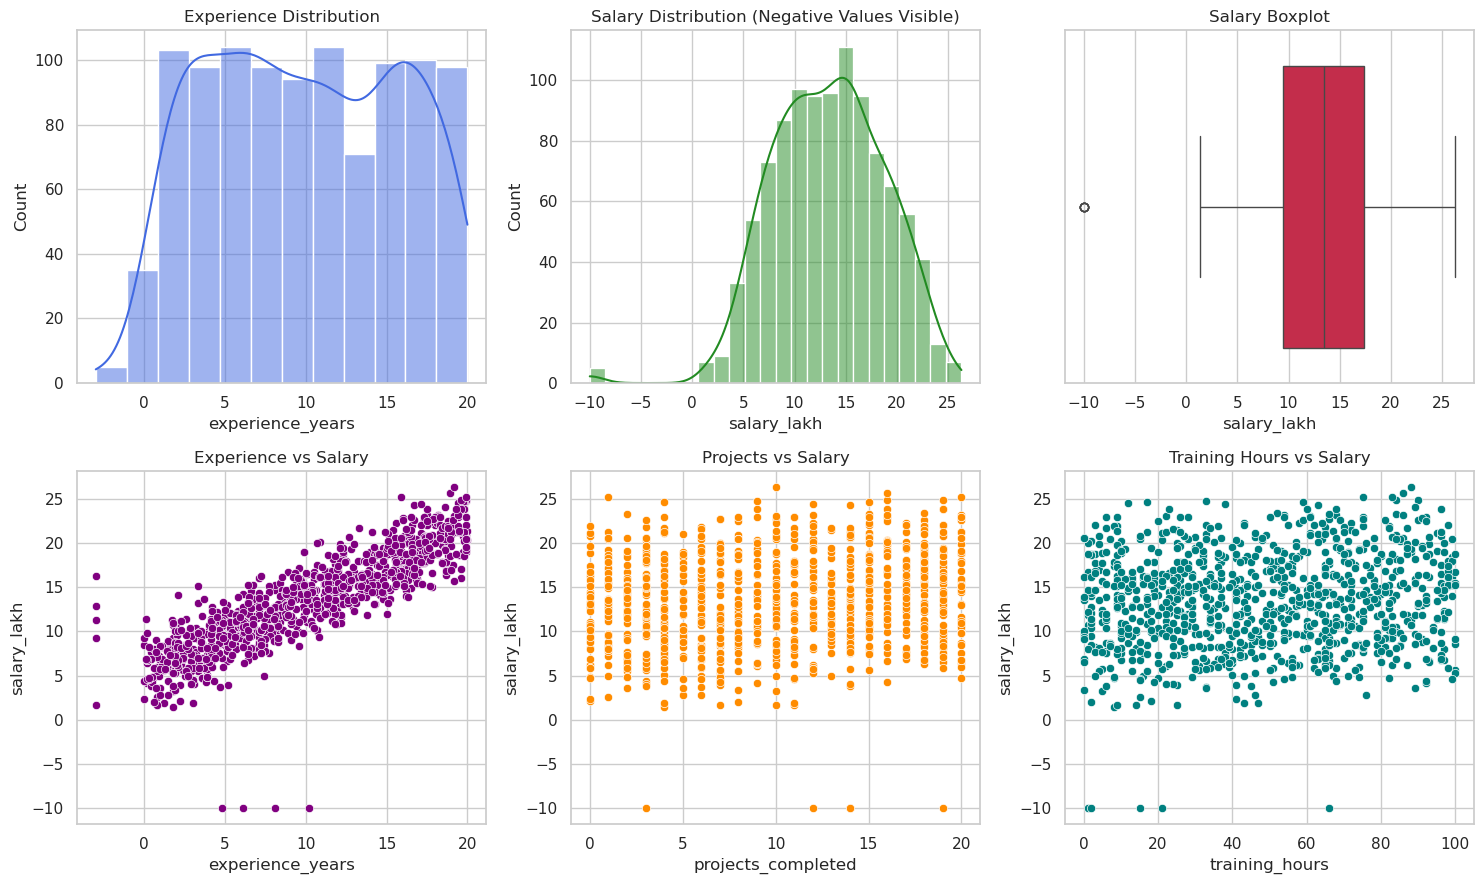

In [13]:
sns.set_theme(style='whitegrid')
fig, axes = plt.subplots(2, 3, figsize=(15, 9))

# Distributions
sns.histplot(
    df['experience_years'], kde=True, ax=axes[0, 0], color='royalblue'
)
axes[0, 0].set_title('Experience Distribution')

sns.histplot(df['salary_lakh'], kde=True, ax=axes[0, 1], color='forestgreen')
axes[0, 1].set_title('Salary Distribution (Negative Values Visible)')

# Outliers check
sns.boxplot(x=df['salary_lakh'], ax=axes[0, 2], color='crimson')
axes[0, 2].set_title('Salary Boxplot')

# Scatter plots against salary
sns.scatterplot(
    data=df, x='experience_years', y='salary_lakh', ax=axes[1, 0], color='purple'
)
axes[1, 0].set_title('Experience vs Salary')

sns.scatterplot(
    data=df,
    x='projects_completed',
    y='salary_lakh',
    ax=axes[1, 1],
    color='darkorange',
)
axes[1, 1].set_title('Projects vs Salary')

sns.scatterplot(
    data=df, x='training_hours', y='salary_lakh', ax=axes[1, 2], color='teal'
)
axes[1, 2].set_title('Training Hours vs Salary')

plt.tight_layout()
plt.show()

In [14]:
# 1. Remove duplicate rows
df_clean = df.drop_duplicates().copy()

# 2. Filter out invalid rows
df_clean = df_clean[
    (df_clean['experience_years'].isna() | (df_clean['experience_years'] >= 0))
    & (df_clean['age'].isna() | (df_clean['age'] >= 18))
    & (df_clean['salary_lakh'] >= 0)
]

# 3. Impute missing values with median
cols_to_impute = [
    'experience_years',
    'age',
    'projects_completed',
    'training_hours',
]
for col in cols_to_impute:
  median_val = df_clean[col].median()
  df_clean[col] = df_clean[col].fillna(median_val)

print('Cleaned Dataset Shape:', df_clean.shape)
print('\nMissing Values Remaining:\n', df_clean.isnull().sum())

Cleaned Dataset Shape: (985, 5)

Missing Values Remaining:
 experience_years      0
age                   0
projects_completed    0
training_hours        0
salary_lakh           0
dtype: int64


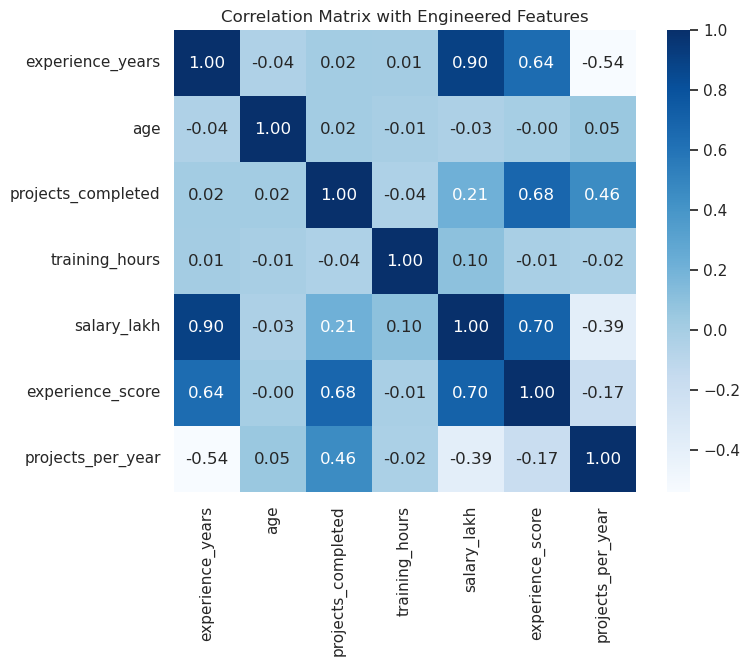

In [15]:
# Feature 1: experience_score
df_clean['experience_score'] = (
    df_clean['experience_years'] * df_clean['projects_completed']
)

# Feature 2: projects_per_year
df_clean['projects_per_year'] = df_clean['projects_completed'] / (
    df_clean['experience_years'] + 1
)

# Heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(df_clean.corr(), annot=True, cmap='Blues', fmt='.2f', square=True)
plt.title('Correlation Matrix with Engineered Features')
plt.show()

In [16]:
# Target is salary_lakh
X = df_clean.drop(columns=['salary_lakh'])
y = df_clean['salary_lakh']

print('Features shape (X):', X.shape)
print('Target shape (y):', y.shape)
print('\nFinal columns ready for training:\n', list(X.columns))

Features shape (X): (985, 6)
Target shape (y): (985,)

Final columns ready for training:
 ['experience_years', 'age', 'projects_completed', 'training_hours', 'experience_score', 'projects_per_year']


In [17]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import train_test_split

# 1. Split data into 80% training and 20% testing
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# 2. Train Linear Regression Model
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)
y_pred_lr = lr_model.predict(X_test)

# 3. Train Random Forest Regressor
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)
y_pred_rf = rf_model.predict(X_test)

# 4. Evaluation Metrics
print('--- Model Evaluation on Test Set ---')
print(f'Linear Regression R² Score: {r2_score(y_test, y_pred_lr):.4f}')
print(
    f'Linear Regression RMSE:    '
    f' {np.sqrt(mean_squared_error(y_test, y_pred_lr)):.4f} Lakh'
)
print(
    f'Linear Regression MAE:     '
    f' {mean_absolute_error(y_test, y_pred_lr):.4f} Lakh\n'
)

print(f'Random Forest R² Score:     {r2_score(y_test, y_pred_rf):.4f}')
print(
    f'Random Forest RMSE:        '
    f' {np.sqrt(mean_squared_error(y_test, y_pred_rf)):.4f} Lakh'
)
print(
    f'Random Forest MAE:         '
    f' {mean_absolute_error(y_test, y_pred_rf):.4f} Lakh'
)

--- Model Evaluation on Test Set ---
Linear Regression R² Score: 0.8429
Linear Regression RMSE:     1.9633 Lakh
Linear Regression MAE:      1.5415 Lakh

Random Forest R² Score:     0.8111
Random Forest RMSE:         2.1528 Lakh
Random Forest MAE:          1.7091 Lakh


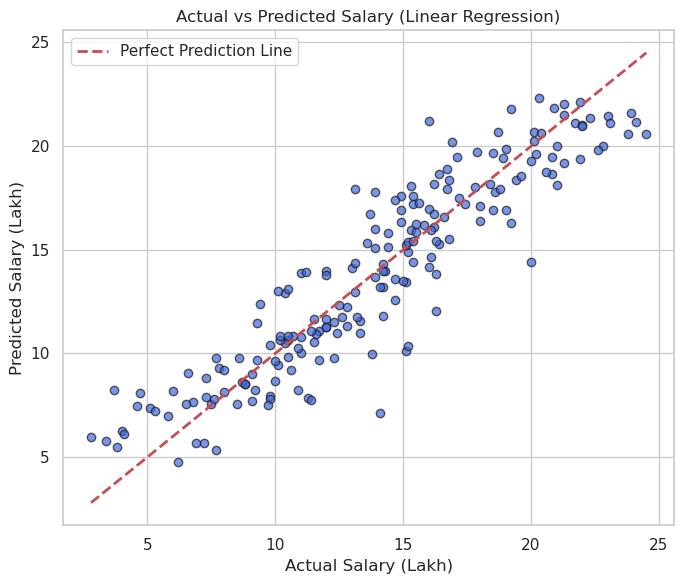

In [18]:
plt.figure(figsize=(7, 6))
plt.scatter(y_test, y_pred_lr, color='royalblue', alpha=0.7, edgecolors='k')
plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    'r--',
    lw=2,
    label='Perfect Prediction Line',
)
plt.xlabel('Actual Salary (Lakh)')
plt.ylabel('Predicted Salary (Lakh)')
plt.title('Actual vs Predicted Salary (Linear Regression)')
plt.legend()
plt.tight_layout()
plt.show()

In [20]:
# Create candidate data with matching feature names
new_candidate = pd.DataFrame(
    [{
        'experience_years': 5.0,
        'age': 26.0,
        'projects_completed': 8.0,
        'training_hours': 40.0,
        'experience_score': 5.0 * 8.0,
        'projects_per_year': 8.0 / (5.0 + 1),
    }]
)

# Predict salary
predicted_salary = lr_model.predict(new_candidate)[0]

print(f'Estimated Salary for Candidate: ₹{predicted_salary:.2f} Lakh/year')

Estimated Salary for Candidate: ₹8.92 Lakh/year
